In [ ]:
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
plt.style.use('dark_background')
warnings.filterwarnings("ignore")

# **CONSTANT**

In [ ]:
DATA_PATH = '/content/drive/MyDrive/DataColab/Agriculture /crop_remmendation_datasetf(class)/dataSets/crop_remmendation_dataset(origial).csv'
ONE_HOT_ENCODE = '/content/onehot_encoder(features).joblib'

#**Read Data**

In [ ]:
df = pd.read_csv(DATA_PATH)
df.head()

,N,P,K,Soil_pH,Soil_Moisture,Soil_Type,Organic_Carbon,Electrical_Conductivity,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Region,Altitude,Season,Irrigation_Type,Fertilizer_Used,Previous_Crop,Recommended_Crop
0,122,55,74,4.54,58.90,Silt,0.77,0.67,25.31,35.15,1403.58,11.03,5.98,West,1947,Kharif,Sprinkler,176.38,Wheat,Sugarcane
1,112,37,25,7.03,25.98,Sandy,0.66,1.94,31.80,54.80,1800.84,4.23,16.17,Central,69,Zaid,Canal,180.05,Cotton,Rice
2,34,52,39,4.95,27.61,Clay,1.36,2.03,15.78,30.88,1336.62,11.45,18.55,West,2049,Kharif,Sprinkler,308.10,Pulses,Barley
3,126,35,82,7.14,39.97,Loamy,1.09,0.30,38.23,47.60,480.85,4.71,4.29,North,930,Rabi,Sprinkler,230.54,Cotton,Millet
4,91,64,51,8.20,33.97,Sandy,0.70,2.07,10.04,72.42,2535.23,11.21,4.41,Central,20,Kharif,Rainfed,63.73,Cotton,Wheat


In [ ]:
df.shape

(10000, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   N                        10000 non-null  int64  
 1   P                        10000 non-null  int64  
 2   K                        10000 non-null  int64  
 3   Soil_pH                  10000 non-null  float64
 4   Soil_Moisture            10000 non-null  float64
 5   Soil_Type                10000 non-null  object 
 6   Organic_Carbon           10000 non-null  float64
 7   Electrical_Conductivity  10000 non-null  float64
 8   Temperature              10000 non-null  float64
 9   Humidity                 10000 non-null  float64
 10  Rainfall                 10000 non-null  float64
 11  Sunlight_Hours           10000 non-null  float64
 12  Wind_Speed               10000 non-null  float64
 13  Region                   10000 non-null  object 
 14  Altitude               

In [ ]:
print('missing value :' , df.isnull().sum().sum())
print('duplicated :' , df.duplicated().sum())

missing value : 0
duplicated : 0


# **Split data to train , test**

In [ ]:
df_train , df_test = train_test_split(df , test_size=0.25 ,
                                      random_state = 42 ,
                                      shuffle=True ,
                                      stratify=df['Recommended_Crop'])
df_test = df_test.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)

In [ ]:
from google.colab import files

# Save the DataFrame to a CSV file
df_test.to_csv('test_data(crop_remmendation).csv', index=False)

# Download the file
files.download('test_data(crop_remmendation).csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(f'Shape of training data: {df_train.shape}')
print(f'Shape of testing data: {df_test.shape}')

Shape of training data: (7500, 20)
Shape of testing data: (2500, 20)


Text(0.5, 0, 'Recommended Crop')

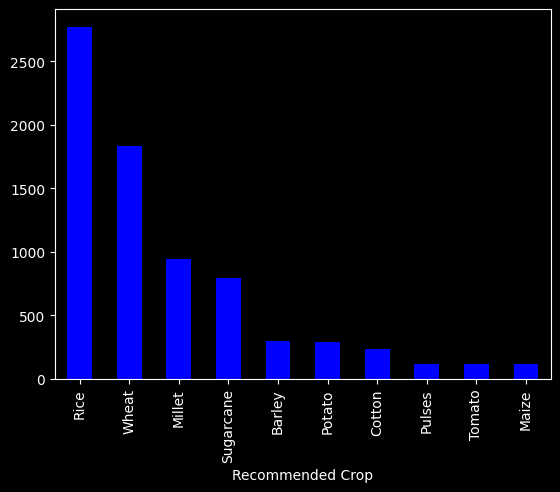

In [ ]:
df_train['Recommended_Crop'].value_counts().plot(kind = 'bar' , color = 'b'  )
plt.xlabel('Recommended Crop' , fontsize = 10)

In [ ]:
df_test['Recommended_Crop'].value_counts()

,count
Recommended_Crop,
Rice,924
Wheat,610
Millet,314
Sugarcane,264
Barley,99
Potato,95
Cotton,78
Pulses,39
Tomato,39


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   N                        7500 non-null   int64  
 1   P                        7500 non-null   int64  
 2   K                        7500 non-null   int64  
 3   Soil_pH                  7500 non-null   float64
 4   Soil_Moisture            7500 non-null   float64
 5   Soil_Type                7500 non-null   object 
 6   Organic_Carbon           7500 non-null   float64
 7   Electrical_Conductivity  7500 non-null   float64
 8   Temperature              7500 non-null   float64
 9   Humidity                 7500 non-null   float64
 10  Rainfall                 7500 non-null   float64
 11  Sunlight_Hours           7500 non-null   float64
 12  Wind_Speed               7500 non-null   float64
 13  Region                   7500 non-null   object 
 14  Altitude                

In [ ]:
df_num = df_train.select_dtypes(include = ['int64' , 'float64' ])
df_cat = df_train.select_dtypes(include = ['object'])

df_target = df_cat['Recommended_Crop']
df_cat = df_cat.drop(['Recommended_Crop'] , axis = 1)

# **Preprocessing (df_train only)**

## **Outlier**

In [ ]:
df_train.head()

,N,P,K,Soil_pH,Soil_Moisture,Soil_Type,Organic_Carbon,Electrical_Conductivity,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Region,Altitude,Season,Irrigation_Type,Fertilizer_Used,Previous_Crop,Recommended_Crop
0,152,54,106,4.62,11.88,Sandy,0.49,2.47,39.55,66.22,2824.88,5.65,15.17,East,1823,Kharif,Rainfed,150.27,Cotton,Rice
1,71,58,62,7.70,23.14,Loamy,0.27,0.78,37.96,54.08,1833.33,5.08,5.45,East,1798,Kharif,Canal,89.11,Maize,Rice
2,28,16,113,6.09,44.27,Clay,0.88,2.65,16.05,62.34,255.25,4.82,10.88,South,1321,Rabi,Sprinkler,91.25,Maize,Wheat
3,24,32,115,5.50,50.86,Clay,0.74,2.17,16.35,79.95,1956.90,10.92,15.69,North,1907,Kharif,Rainfed,274.84,Pulses,Barley
4,93,23,56,6.02,57.19,Loamy,0.41,0.57,38.95,39.00,2876.29,6.43,8.76,South,2384,Zaid,Rainfed,224.69,Rice,Rice


In [ ]:
df_train.describe()

,N,P,K,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Altitude,Fertilizer_Used
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.00000,7500.000000,7500.000000,7500.000000
mean,89.789600,49.744000,64.744267,6.493909,35.102641,0.850431,1.541799,25.113540,60.130732,1581.632548,8.00714,10.526053,1245.881733,200.802700
std,40.272151,23.147798,31.943529,1.146852,14.369716,0.373225,0.834251,8.596662,17.465693,807.123995,2.29249,5.510596,715.664909,86.717502
min,20.000000,10.000000,10.000000,4.500000,10.000000,0.200000,0.100000,10.000000,30.010000,200.080000,4.00000,1.000000,0.000000,50.020000
25%,55.000000,29.000000,37.000000,5.500000,22.747500,0.530000,0.820000,17.620000,44.827500,871.382500,6.02000,5.720000,637.000000,126.447500
50%,90.000000,50.000000,65.000000,6.500000,35.260000,0.850000,1.540000,25.185000,60.455000,1580.040000,8.03000,10.520000,1233.000000,200.150000
75%,125.000000,70.000000,93.000000,7.480000,47.410000,1.170000,2.270000,32.522500,75.542500,2272.435000,9.98000,15.350000,1867.250000,276.162500
max,159.000000,89.000000,119.000000,8.500000,59.990000,1.500000,3.000000,40.000000,89.990000,2999.980000,12.00000,20.000000,2499.000000,349.930000


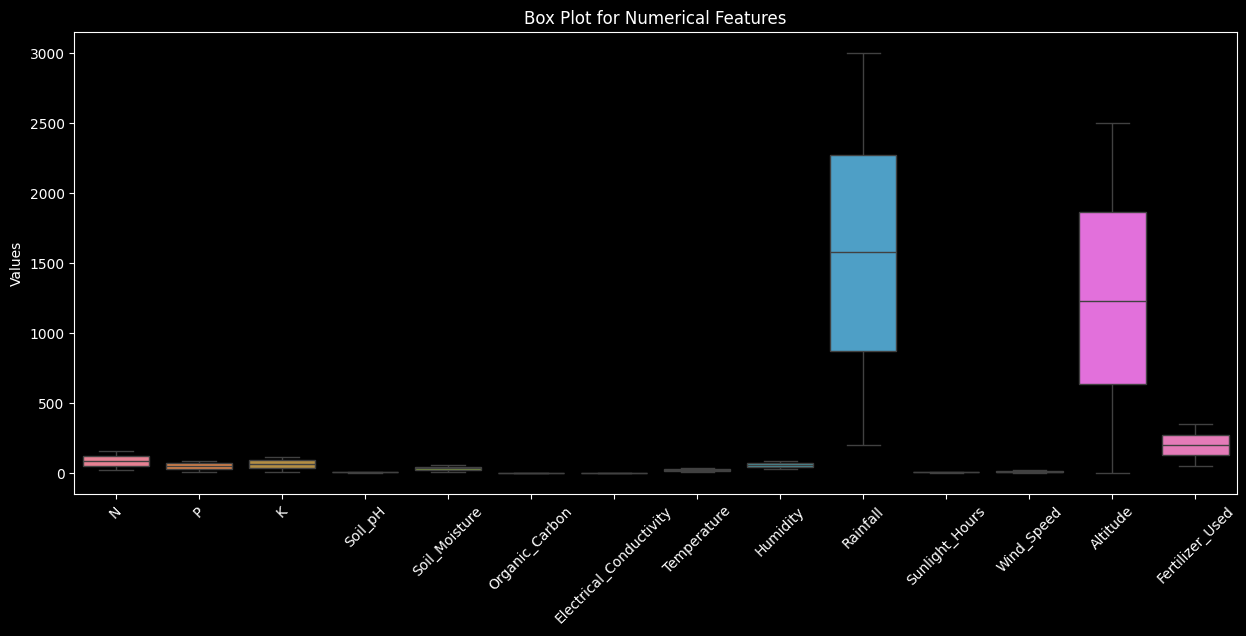

In [ ]:
numeric_cols = df_train.select_dtypes(include=['int64', 'float64'])
import seaborn as sns
plt.figure(figsize=(15, 6))
sns.boxplot(numeric_cols)
plt.xticks(rotation=45)
plt.title("Box Plot for Numerical Features")
plt.ylabel("Values")
plt.show()

## **Encoder**

In [ ]:
df_cat.head()

,Soil_Type,Region,Season,Irrigation_Type,Previous_Crop
0,Sandy,East,Kharif,Rainfed,Cotton
1,Loamy,East,Kharif,Canal,Maize
2,Clay,South,Rabi,Sprinkler,Maize
3,Clay,North,Kharif,Rainfed,Pulses
4,Loamy,South,Zaid,Rainfed,Rice


oneHotEncode for cat feature


In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output = False) # output is dense array

df_cat_encoder_array = encoder.fit_transform(df_cat)
df_encoder_dataFrame = pd.DataFrame(df_cat_encoder_array , columns = encoder.get_feature_names_out(df_cat.columns))

features = pd.concat(
    [df_num, df_encoder_dataFrame],
    axis=1
)


In [ ]:
features.head()

,N,P,K,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Altitude,Fertilizer_Used,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Silt,Region_Central,Region_East,Region_North,Region_South,Region_West,Season_Kharif,Season_Rabi,Season_Zaid,Irrigation_Type_Canal,Irrigation_Type_Drip,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Previous_Crop_Cotton,Previous_Crop_Maize,Previous_Crop_Pulses,Previous_Crop_Rice,Previous_Crop_Vegetables,Previous_Crop_Wheat
0,152,54,106,4.62,11.88,0.49,2.47,39.55,66.22,2824.88,5.65,15.17,1823,150.27,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,71,58,62,7.70,23.14,0.27,0.78,37.96,54.08,1833.33,5.08,5.45,1798,89.11,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,28,16,113,6.09,44.27,0.88,2.65,16.05,62.34,255.25,4.82,10.88,1321,91.25,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,24,32,115,5.50,50.86,0.74,2.17,16.35,79.95,1956.90,10.92,15.69,1907,274.84,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,93,23,56,6.02,57.19,0.41,0.57,38.95,39.00,2876.29,6.43,8.76,2384,224.69,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


**Label encode for target**

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
df_target.head()

,Recommended_Crop
0,Rice
1,Rice
2,Wheat
3,Barley
4,Rice


In [ ]:
from sklearn.preprocessing import LabelEncoder
LabelEncode = LabelEncoder()

target = LabelEncode.fit_transform(df_target)

In [ ]:
label_mapping = dict ( zip( LabelEncode.classes_ , LabelEncode.transform(LabelEncode.classes_) ) )
label_mapping # importat

{'Barley': np.int64(0),
 'Cotton': np.int64(1),
 'Maize': np.int64(2),
 'Millet': np.int64(3),
 'Potato': np.int64(4),
 'Pulses': np.int64(5),
 'Rice': np.int64(6),
 'Sugarcane': np.int64(7),
 'Tomato': np.int64(8),
 'Wheat': np.int64(9)}

In [ ]:
import joblib
from google.colab import files

# Define the filename for saving the encoder
encoder_filename = 'onehot_encoder(features).joblib'

# Save the fitted encoder
joblib.dump(encoder, encoder_filename)

print(f"OneHotEncoder saved successfully to {encoder_filename}")

# Download the saved encoder file
files.download('onehot_encoder(features).joblib')




# Define the filename for saving the encoder
encoder_filename = 'label_encoder(target).joblib'

# Save the fitted encoder
joblib.dump(LabelEncode, encoder_filename)

print(f"LabelEncoder saved successfully to {encoder_filename}")

# Download the saved encoder file
files.download('label_encoder(target).joblib')

OneHotEncoder saved successfully to onehot_encoder(features).joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

LabelEncoder saved successfully to label_encoder(target).joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Feature Engineering**

### **Feature Extraction**

In [ ]:
features.head()

,N,P,K,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Altitude,Fertilizer_Used,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Silt,Region_Central,Region_East,Region_North,Region_South,Region_West,Season_Kharif,Season_Rabi,Season_Zaid,Irrigation_Type_Canal,Irrigation_Type_Drip,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Previous_Crop_Cotton,Previous_Crop_Maize,Previous_Crop_Pulses,Previous_Crop_Rice,Previous_Crop_Vegetables,Previous_Crop_Wheat
0,152,54,106,4.62,11.88,0.49,2.47,39.55,66.22,2824.88,5.65,15.17,1823,150.27,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,71,58,62,7.70,23.14,0.27,0.78,37.96,54.08,1833.33,5.08,5.45,1798,89.11,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,28,16,113,6.09,44.27,0.88,2.65,16.05,62.34,255.25,4.82,10.88,1321,91.25,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,24,32,115,5.50,50.86,0.74,2.17,16.35,79.95,1956.90,10.92,15.69,1907,274.84,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,93,23,56,6.02,57.19,0.41,0.57,38.95,39.00,2876.29,6.43,8.76,2384,224.69,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
features.columns

Index(['N', 'P', 'K', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature', 'Humidity', 'Rainfall',
       'Sunlight_Hours', 'Wind_Speed', 'Altitude', 'Fertilizer_Used',
       'Soil_Type_Clay', 'Soil_Type_Loamy', 'Soil_Type_Sandy',
       'Soil_Type_Silt', 'Region_Central', 'Region_East', 'Region_North',
       'Region_South', 'Region_West', 'Season_Kharif', 'Season_Rabi',
       'Season_Zaid', 'Irrigation_Type_Canal', 'Irrigation_Type_Drip',
       'Irrigation_Type_Rainfed', 'Irrigation_Type_Sprinkler',
       'Previous_Crop_Cotton', 'Previous_Crop_Maize', 'Previous_Crop_Pulses',
       'Previous_Crop_Rice', 'Previous_Crop_Vegetables',
       'Previous_Crop_Wheat'],
      dtype='object')



**1️⃣ First: what matters for crop recommendation**

Crop type depends mainly on:

* **Soil fertility & chemistry** (NPK, pH, EC, Organic Carbon)
* **Water availability** (rainfall, moisture, humidity)
* **Climate & energy** (temperature, sunlight)
* **Geography** (altitude)
* **Management** (fertilizer used)

---

 2️⃣ **High-value feature extraction (recommended)**

 A) Nutrient features (VERY important)

```text
NPK_sum = N + P + K
N_to_P = N / (P + 1)
N_to_K = N / (K + 1)
P_to_K = P / (K + 1)
NPK_balance = max(N,P,K) - min(N,P,K)
```

📌 Crops care more about **balance** than absolute numbers.

---

 B) **Soil chemistry**

```text
pH_distance = |Soil_pH - 7|
EC_log = log(1 + Electrical_Conductivity)
Fertility_index = Organic_Carbon × NPK_sum
```

📌 Many crops have **tight pH ranges**.

---

 C) **Water & climate interactions**

```text
Moisture_Rain = Soil_Moisture × Rainfall
Temp_Humidity = Temperature × Humidity
Heat_Load = Temperature × Sunlight_Hours
Dryness_Index = Temperature / (Humidity + 1)
```

📌 These interactions often outperform raw features.

---

 D) **Geography**

```text
Altitude_Temp = Altitude × Temperature
```

---

 E) **Fertilizer handling**

* If **categorical** → One-Hot Encode
* If **numeric**:

```text
Fert_NPK_interaction = Fertilizer_Used × NPK_sum
```

---

In [ ]:
# @title
def feature_extraction(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create engineered (extracted) features for crop-type recommendation.

    Expected columns:
    N, P, K, Soil_pH, Soil_Moisture, Organic_Carbon, Electrical_Conductivity,
    Temperature, Humidity, Rainfall, Sunlight_Hours, Wind_Speed, Altitude,
    Fertilizer_Used (optional / numeric)
    """
    X = df.copy()
    eps = 1e-9  # to avoid divide-by-zero

    # --- Nutrient (NPK) features ---
    X["NPK_sum"] = X["N"] + X["P"] + X["K"]
    X["N_ratio"] = X["N"] / (X["NPK_sum"] + eps)
    X["P_ratio"] = X["P"] / (X["NPK_sum"] + eps)
    X["K_ratio"] = X["K"] / (X["NPK_sum"] + eps)

    X["N_to_P"] = X["N"] / (X["P"] + 1.0)
    X["N_to_K"] = X["N"] / (X["K"] + 1.0)
    X["P_to_K"] = X["P"] / (X["K"] + 1.0)

    X["NPK_balance"] = X[["N", "P", "K"]].max(axis=1) - X[["N", "P", "K"]].min(axis=1)

    # --- Soil chemistry features ---
    X["pH_distance"] = (X["Soil_pH"] - 7.0).abs()
    X["EC_log"] = np.log1p(X["Electrical_Conductivity"].clip(lower=0))

    # organic carbon context
    X["Fertility_index"] = X["Organic_Carbon"] * (X["NPK_sum"] + eps)
    X["OC_to_NPK"] = X["Organic_Carbon"] / (X["NPK_sum"] + 1.0)

    # --- Water / climate interaction features ---
    X["Moisture_Rain"] = X["Soil_Moisture"] * X["Rainfall"]
    X["Temp_Humidity"] = X["Temperature"] * X["Humidity"]
    X["Heat_Load"] = X["Temperature"] * X["Sunlight_Hours"]
    X["SunRain_ratio"] = X["Sunlight_Hours"] / (X["Rainfall"] + 1.0)
    X["Dryness_Index"] = X["Temperature"] / (X["Humidity"] + 1.0)

    # --- Geography interaction ---
    X["Altitude_Temp"] = X["Altitude"] * X["Temperature"]

    # --- Fertilizer interaction (only if Fertilizer_Used is numeric) ---
    if "Fertilizer_Used" in X.columns and pd.api.types.is_numeric_dtype(X["Fertilizer_Used"]):
        X["Fert_NPK_interaction"] = X["Fertilizer_Used"] * (X["NPK_sum"] + eps)

    return X


# Example:



In [ ]:
feature_with_extract = features

In [ ]:
feature_with_extract.head()

,N,P,K,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Altitude,Fertilizer_Used,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Silt,Region_Central,Region_East,Region_North,Region_South,Region_West,Season_Kharif,Season_Rabi,Season_Zaid,Irrigation_Type_Canal,Irrigation_Type_Drip,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Previous_Crop_Cotton,Previous_Crop_Maize,Previous_Crop_Pulses,Previous_Crop_Rice,Previous_Crop_Vegetables,Previous_Crop_Wheat
0,152,54,106,4.62,11.88,0.49,2.47,39.55,66.22,2824.88,5.65,15.17,1823,150.27,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,71,58,62,7.70,23.14,0.27,0.78,37.96,54.08,1833.33,5.08,5.45,1798,89.11,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,28,16,113,6.09,44.27,0.88,2.65,16.05,62.34,255.25,4.82,10.88,1321,91.25,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,24,32,115,5.50,50.86,0.74,2.17,16.35,79.95,1956.90,10.92,15.69,1907,274.84,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,93,23,56,6.02,57.19,0.41,0.57,38.95,39.00,2876.29,6.43,8.76,2384,224.69,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
feature_with_extract.shape

(7500, 36)

###**Feature Selection**

In [ ]:
print(feature_with_extract.shape)

(7500, 36)


In [ ]:
feature_with_extract.head()

,N,P,K,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Altitude,Fertilizer_Used,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Silt,Region_Central,Region_East,Region_North,Region_South,Region_West,Season_Kharif,Season_Rabi,Season_Zaid,Irrigation_Type_Canal,Irrigation_Type_Drip,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Previous_Crop_Cotton,Previous_Crop_Maize,Previous_Crop_Pulses,Previous_Crop_Rice,Previous_Crop_Vegetables,Previous_Crop_Wheat
0,152,54,106,4.62,11.88,0.49,2.47,39.55,66.22,2824.88,5.65,15.17,1823,150.27,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,71,58,62,7.70,23.14,0.27,0.78,37.96,54.08,1833.33,5.08,5.45,1798,89.11,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,28,16,113,6.09,44.27,0.88,2.65,16.05,62.34,255.25,4.82,10.88,1321,91.25,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,24,32,115,5.50,50.86,0.74,2.17,16.35,79.95,1956.90,10.92,15.69,1907,274.84,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,93,23,56,6.02,57.19,0.41,0.57,38.95,39.00,2876.29,6.43,8.76,2384,224.69,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
from sklearn.feature_selection import mutual_info_classif

discrete_mask = [
    (feature_with_extract[col].nunique() <= 10)
    for col in feature_with_extract.columns
]


MI = mutual_info_classif(feature_with_extract , target , discrete_features = discrete_mask , random_state=42)

MI = pd.DataFrame({'features' :feature_with_extract.columns , 'mi':MI}).sort_values(['mi'] , ascending=False).reset_index(drop= True)
# features With Target
print('MI DF shape : ' ,MI.shape)

MI DF shape :  (36, 2)


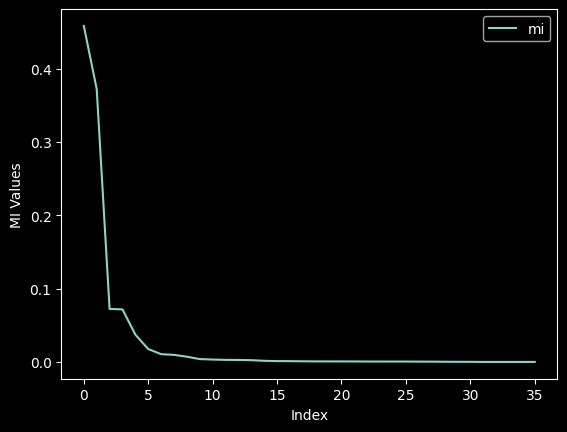

In [ ]:
MI.plot()
plt.xlabel('Index')
plt.ylabel('MI Values')
plt.show()

`We take only 20 features`

In [ ]:
MI = MI[1:20]

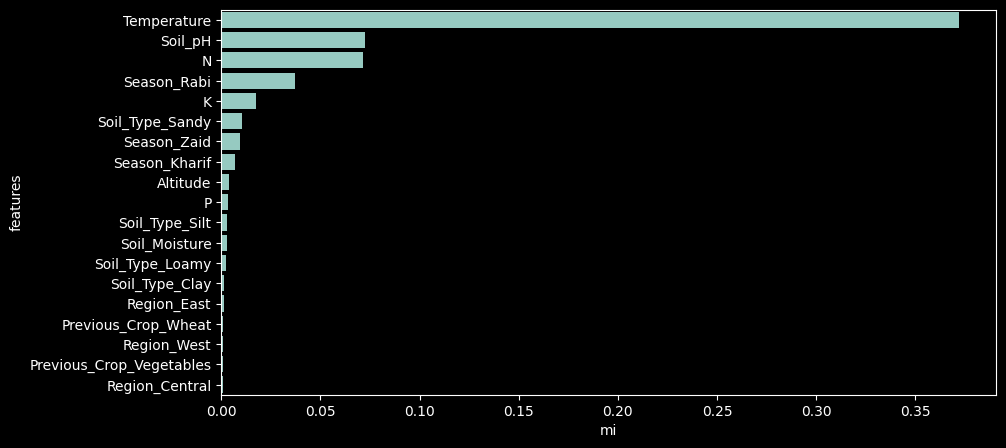

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(MI, x="mi", y="features" , )
plt.show()

In [ ]:
MI_columns = MI.features.tolist()
len (MI_columns)

19

In [ ]:
features_after_FS = feature_with_extract[MI_columns]
features_after_FS.head()

,Temperature,Soil_pH,N,Season_Rabi,K,Soil_Type_Sandy,Season_Zaid,Season_Kharif,Altitude,P,Soil_Type_Silt,Soil_Moisture,Soil_Type_Loamy,Soil_Type_Clay,Region_East,Previous_Crop_Wheat,Region_West,Previous_Crop_Vegetables,Region_Central
0,39.55,4.62,152,0.0,106,1.0,0.0,1.0,1823,54,0.0,11.88,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,37.96,7.70,71,0.0,62,0.0,0.0,1.0,1798,58,0.0,23.14,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,16.05,6.09,28,1.0,113,0.0,0.0,0.0,1321,16,0.0,44.27,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,16.35,5.50,24,0.0,115,0.0,0.0,1.0,1907,32,0.0,50.86,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,38.95,6.02,93,0.0,56,0.0,1.0,0.0,2384,23,0.0,57.19,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print(features_after_FS.shape)

(7500, 19)


In [ ]:
x = feature_with_extract[features_after_FS.columns]
x.head()

,Temperature,Soil_pH,N,Season_Rabi,K,Soil_Type_Sandy,Season_Zaid,Season_Kharif,Altitude,P,Soil_Type_Silt,Soil_Moisture,Soil_Type_Loamy,Soil_Type_Clay,Region_East,Previous_Crop_Wheat,Region_West,Previous_Crop_Vegetables,Region_Central
0,39.55,4.62,152,0.0,106,1.0,0.0,1.0,1823,54,0.0,11.88,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,37.96,7.70,71,0.0,62,0.0,0.0,1.0,1798,58,0.0,23.14,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,16.05,6.09,28,1.0,113,0.0,0.0,0.0,1321,16,0.0,44.27,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,16.35,5.50,24,0.0,115,0.0,0.0,1.0,1907,32,0.0,50.86,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,38.95,6.02,93,0.0,56,0.0,1.0,0.0,2384,23,0.0,57.19,1.0,0.0,0.0,0.0,0.0,0.0,0.0


**for pipeline**

In [ ]:
features_after_FS.columns

Index(['Temperature', 'Soil_pH', 'N', 'Season_Rabi', 'K', 'Soil_Type_Sandy',
       'Season_Zaid', 'Season_Kharif', 'Altitude', 'P', 'Soil_Type_Silt',
       'Soil_Moisture', 'Soil_Type_Loamy', 'Soil_Type_Clay', 'Region_East',
       'Previous_Crop_Wheat', 'Region_West', 'Previous_Crop_Vegetables',
       'Region_Central'],
      dtype='object')

In [ ]:
def feature_selection(feature_with_extract: pd.DataFrame) -> pd.DataFrame:
  x = feature_with_extract[['Temperature', 'SunRain_ratio', 'Moisture_Rain', 'Dryness_Index',
       'Heat_Load', 'Temp_Humidity', 'Soil_pH', 'N', 'Altitude_Temp',
       'pH_distance', 'Season_Rabi', 'N_ratio', 'N_to_P', 'NPK_balance',
       'NPK_sum', 'K_ratio', 'N_to_K', 'Soil_Type_Sandy', 'OC_to_NPK']]
  return x


### **Transformation**

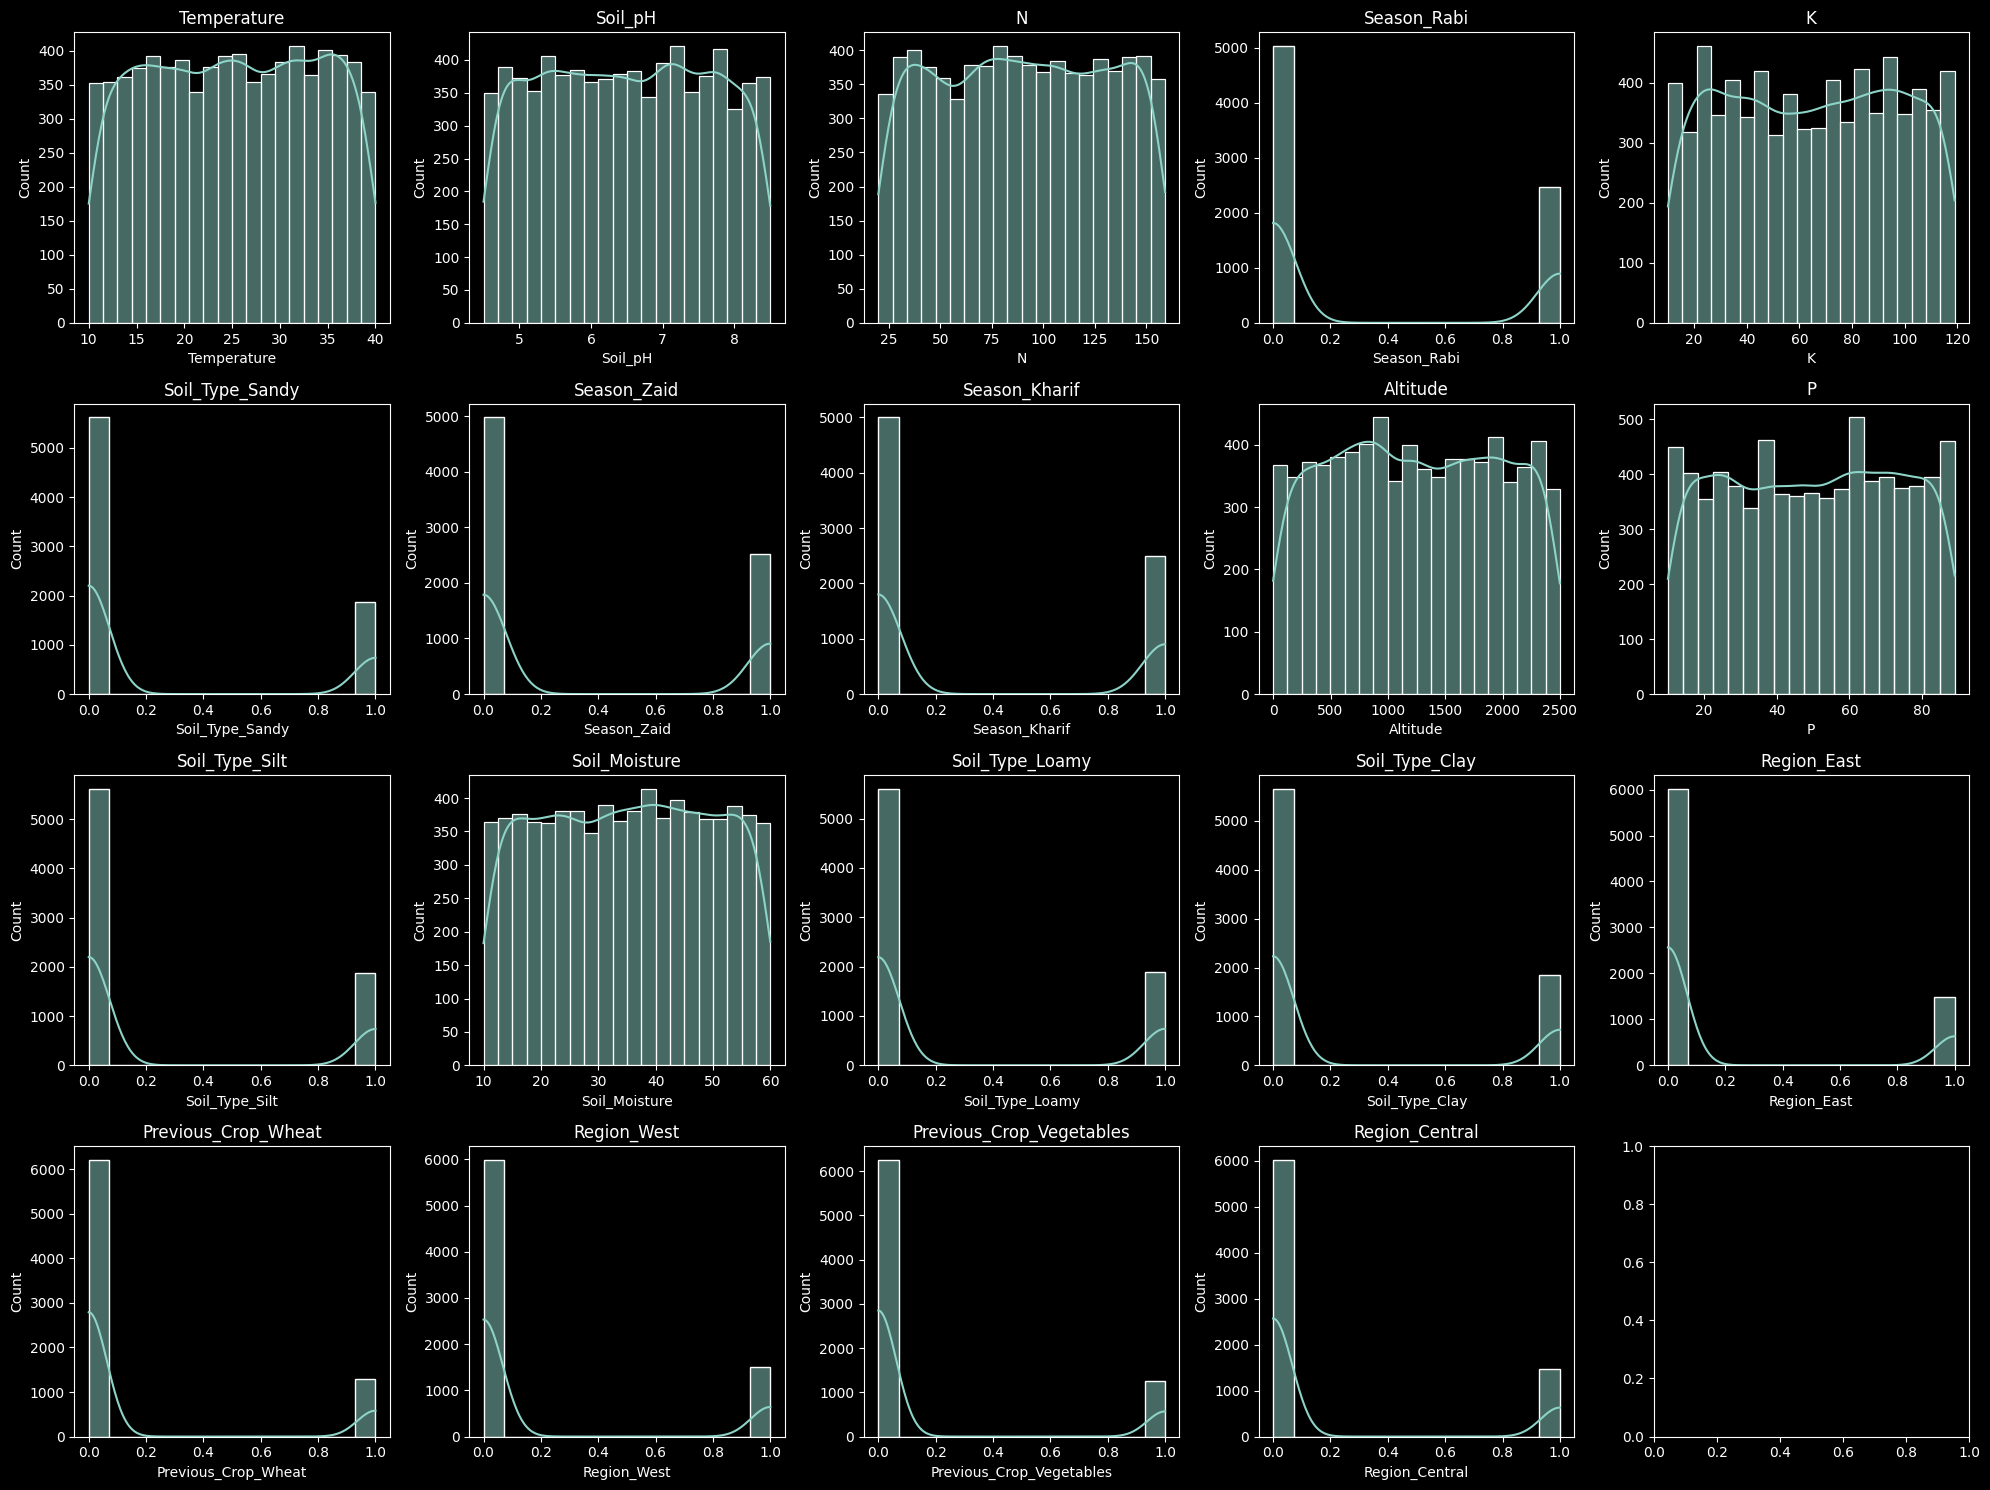

In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(features_after_FS.columns):
    sns.histplot(
        features_after_FS[col],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
X_gaussian = pt.fit_transform(features_after_FS)

X_gaussian = pd.DataFrame(
    X_gaussian,
    columns=features_after_FS.columns
)

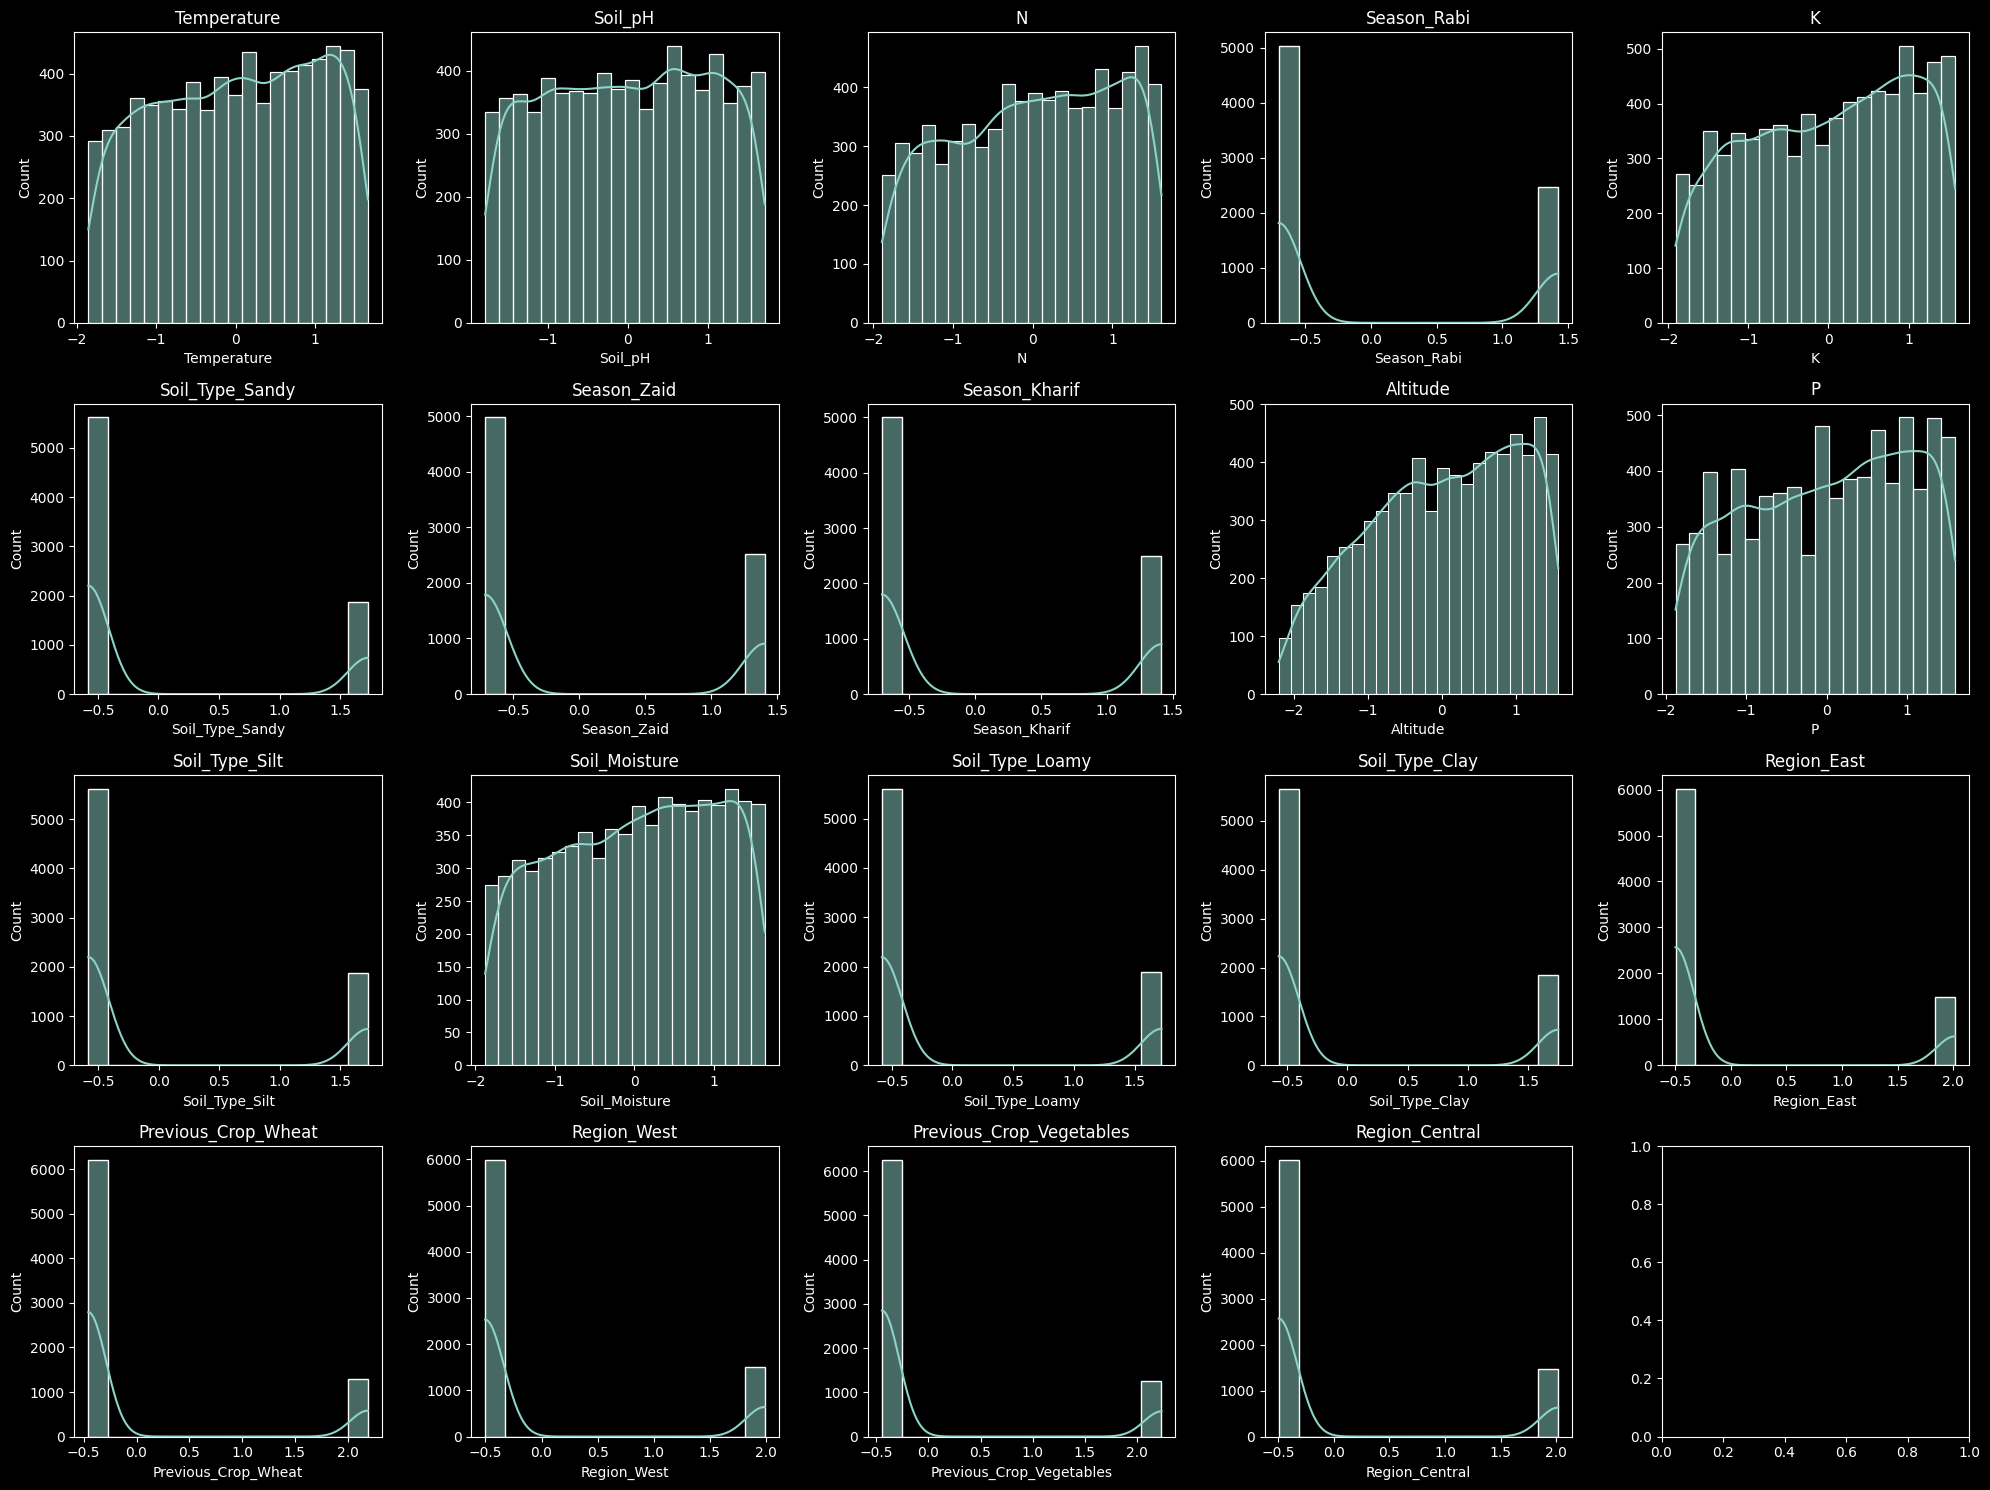

In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(X_gaussian.columns):
    sns.histplot(
        X_gaussian[col],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


In [ ]:
X_gaussian.head()

,Temperature,Soil_pH,N,Season_Rabi,K,Soil_Type_Sandy,Season_Zaid,Season_Kharif,Altitude,P,Soil_Type_Silt,Soil_Moisture,Soil_Type_Loamy,Soil_Type_Clay,Region_East,Previous_Crop_Wheat,Region_West,Previous_Crop_Vegetables,Region_Central,target
0,1.615468,-1.667597,1.466982,-0.701810,1.238529,1.729591,-0.712417,1.414214,0.814211,0.238211,-0.579198,-1.709733,-0.581045,-0.570986,2.015973,-0.4562,-0.502707,-0.446784,-0.495621,6
1,1.448645,1.048712,-0.409561,-0.701810,-0.013490,-0.578171,-0.712417,1.414214,0.784771,0.401898,-0.579198,-0.805481,1.721036,-0.570986,2.015973,-0.4562,-0.502707,-0.446784,-0.495621,6
2,-1.052065,-0.334741,-1.624785,1.424887,1.423784,-0.578171,-0.712417,-0.707107,0.197114,-1.529558,-0.579198,0.659395,-0.581045,1.751355,-0.496038,-0.4562,-0.502707,-0.446784,-0.495621,9
3,-1.014227,-0.860618,-1.755277,-0.701810,1.476160,-0.578171,-0.712417,1.414214,0.912277,-0.724061,-0.579198,1.079880,-0.581045,1.751355,-0.496038,-0.4562,-0.502707,-0.446784,-0.495621,0
4,1.552688,-0.396551,0.136177,-0.701810,-0.199861,-0.578171,1.403673,-0.707107,1.447182,-1.161040,-0.579198,1.472122,1.721036,-0.570986,-0.496038,-0.4562,-0.502707,-0.446784,-0.495621,6


### **LDA**

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
n_classes = len(np.unique(target))
n_components = min(X_gaussian.shape[1], n_classes - 1)

lda = LinearDiscriminantAnalysis(n_components=n_components)
X_train_lda = lda.fit_transform(X_gaussian, target)

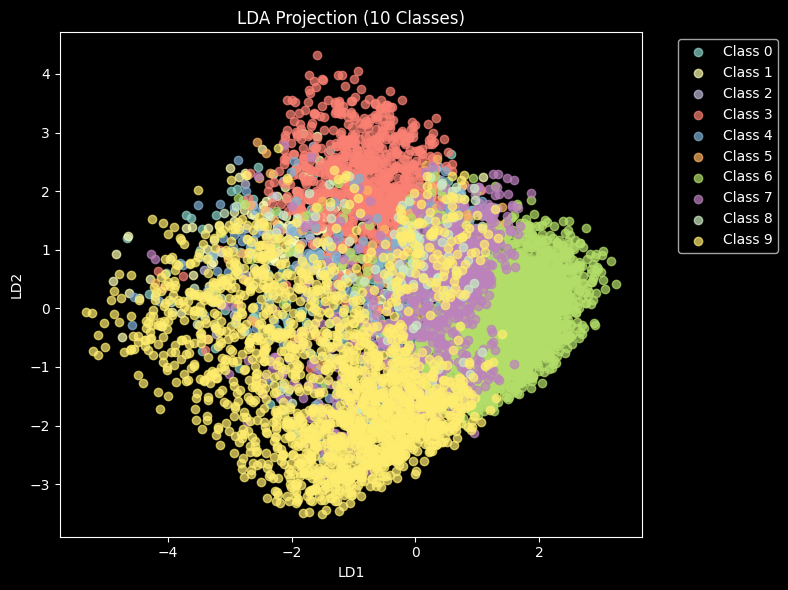

In [ ]:
plt.figure(figsize=(8, 6))

for c in np.unique(target):
    plt.scatter(
        X_train_lda[target == c, 0],
        X_train_lda[target == c, 1],
        label=f"Class {c}",
        alpha=0.7
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection (10 Classes)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
final_df = pd.DataFrame(X_train_lda , columns = [f"LD{i+1}" for i in range(n_components)])
final_df['target'] = target

### **Solve Imbalanced data**

In [ ]:
final_df['target'].value_counts()

,count
target,
6,2773
9,1830
3,941
7,790
0,297
4,287
1,235
5,117
8,117


`we make all classes < 1000`
`but Now we will use class_weight='balanced' in our Model`

### **Final Preprocessing (Result)**

In [ ]:
final_df.head()

,LD1,LD2,LD3,LD4,LD5,LD6,LD7,LD8,LD9,target
0,2.705517,1.043451,-2.325842,-0.265080,-0.153016,0.576329,-0.914319,0.229731,-0.363052,6
1,1.183871,0.294492,1.311305,-1.922766,-0.699789,-0.870149,-0.954513,0.794721,-0.280757,6
2,-4.076827,1.455201,1.609056,1.240158,1.130050,-0.106601,-1.486629,0.827093,0.553869,9
3,-0.236668,-0.736233,0.459595,1.318138,-0.973054,-0.386289,-0.832243,1.126196,1.745144,0
4,2.286663,0.289125,0.348703,-1.414179,-0.040101,-0.402979,-1.298652,1.700397,-1.148789,6


In [ ]:
# from google.colab import files

# # Save the DataFrame to a CSV file
# final_df.to_csv('final_processed_data(crop_remmendation).csv', index=False)

# # Download the file
# files.download('final_processed_data(crop_remmendation).csv')

# **Pipeline**

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

In [ ]:
numerical_columns = [
    col for col in features_after_FS.columns
    if features_after_FS[col].nunique() >= 10
]

Categorical_columns = [
    col for col in features_after_FS.columns
    if features_after_FS[col].nunique() <= 10
]

In [ ]:
def Encode(df_origin : pd.DataFrame) -> pd.DataFrame :


  loaded_encoder = joblib.load(ONE_HOT_ENCODE)

  df_num = df_origin.select_dtypes(include = ['int64' , 'float64' ])
  df_cat = df_origin.select_dtypes(include = ['object'])

  df_cat_encoder_array = loaded_encoder.transform(df_cat)
  df_encoder_dataFrame = pd.DataFrame(df_cat_encoder_array , columns = loaded_encoder.get_feature_names_out(df_cat.columns))

  x = pd.concat(
      [df_num, df_encoder_dataFrame],
      axis=1
  )
  return x

In [ ]:
Encoder = FunctionTransformer(Encode, validate=False)

FeaturesExtraction = FunctionTransformer(feature_extraction, validate=False)

FeaturesSelection  = FunctionTransformer(feature_selection, validate=False) # you should make feature_selection

In [ ]:
Transformer = ColumnTransformer(transformers=[
    ('PowerTransform' , PowerTransformer(method='yeo-johnson'),numerical_columns),
],remainder="passthrough" )

In [ ]:
pipe = Pipeline(steps = [
    ('Encoding' , Encoder),
    ('FeaturesExtract' , FeaturesExtraction),
    ('FeaturesSelect' , FeaturesSelection),
    ('PowerTransform' , Transformer),
    ('LDA' , lda)
])

In [ ]:
y = df_train['Recommended_Crop' ]
x = df_train.drop('Recommended_Crop' , axis = 1)

pipe.fit(x , y )
pipe

Pipeline(steps=[('Encoding',
                 FunctionTransformer(func=<function Encode at 0x7eccf1170ea0>)),
                ('FeaturesExtract',
                 FunctionTransformer(func=<function feature_extraction at 0x7eccf9c0b920>)),
                ('FeaturesSelect',
                 FunctionTransformer(func=<function feature_selection at 0x7eccf6c9b7e0>)),
                ('PowerTransform',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('PowerTransform',
                                                  PowerTransformer(),
                                                  ['Temperature',
                                                   'SunRain_ratio',
                                                   'Moisture_Rain',
                                                   'Dryness_Index', 'Heat_Load',
                                                   'Temp_Humidity', 'Soil_pH',
                                                   'N', 'Altitude_Temp',
                                                   'pH_distance', 'N_ratio',
                                                   'N_to_P', 'NPK_balance',
                                                   'NPK_sum', 'K_ratio',
                                                   'N_to_K', 'OC_to_NPK'])])),
                ('LDA', LinearDiscriminantAnalysis(n_components=9))])

### **Save pipeline**

In [ ]:
import joblib
from google.colab import files


pipeline_filename = 'crop_recommendation_pipeline(Preprocessing).joblib'

joblib.dump(pipe, pipeline_filename)
print(f"Pipeline saved successfully to {pipeline_filename}")


# Download the saved pipeline file
files.download('crop_recommendation_pipeline(Preprocessing).joblib')

Pipeline saved successfully to crop_recommendation_pipeline(Preprocessing).joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **Test Pipleline**

In [ ]:
input = df_train.drop('Recommended_Crop' , axis = 1)
input = pipe.transform(input)
pd.DataFrame(input).head()

,0,1,2,3,4,5,6,7,8
0,2.705517,1.043451,-2.325842,-0.265080,-0.153016,0.576329,-0.914319,0.229731,-0.363052
1,1.183871,0.294492,1.311305,-1.922766,-0.699789,-0.870149,-0.954513,0.794721,-0.280757
2,-4.076827,1.455201,1.609056,1.240158,1.130050,-0.106601,-1.486629,0.827093,0.553869
3,-0.236668,-0.736233,0.459595,1.318138,-0.973054,-0.386289,-0.832243,1.126196,1.745144
4,2.286663,0.289125,0.348703,-1.414179,-0.040101,-0.402979,-1.298652,1.700397,-1.148789


In [ ]:
final_df.head()

,LD1,LD2,LD3,LD4,LD5,LD6,LD7,LD8,LD9,target
0,2.705517,1.043451,-2.325842,-0.265080,-0.153016,0.576329,-0.914319,0.229731,-0.363052,6
1,1.183871,0.294492,1.311305,-1.922766,-0.699789,-0.870149,-0.954513,0.794721,-0.280757,6
2,-4.076827,1.455201,1.609056,1.240158,1.130050,-0.106601,-1.486629,0.827093,0.553869,9
3,-0.236668,-0.736233,0.459595,1.318138,-0.973054,-0.386289,-0.832243,1.126196,1.745144,0
4,2.286663,0.289125,0.348703,-1.414179,-0.040101,-0.402979,-1.298652,1.700397,-1.148789,6


# **Finish**